# 🔋 IE Datathon March 2026 — Intelligent Electric Mobility (Iberdrola)
## Designing Tomorrow's Charging Network

**Scope:** Interurban roads in Spain — autopistas (AP-), autovías (A-), carreteras nacionales (N-)
**Target Horizon:** 2027

| # | Source | URL |
|---|--------|-----|
| 1 | Road Routes — Ministry of Transport | https://www.transportes.gob.es/carreteras/catalogo-y-evolucion-de-la-red-de-carreteras/archivos-geometrias-rce |
| 2 | Existing EV Charging Points — NAP/DGT | https://nap.dgt.es/en/dataset/puntos-de-recarga-electrica-para-vehiculos |
| 3 | EV Growth Projections — datos.gob.es GitHub | https://github.com/Admindatosgobes/Laboratorio-de-Datos |

---

## 0. Setup — Install & Import Libraries

In [ ]:
!pip install folium geopandas pandas requests lxml shapely openpyxl fiona pyproj branca scipy -q

In [ ]:
import os, json, zipfile, io, subprocess, warnings, glob
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
from folium.plugins import MarkerCluster, HeatMap
from lxml import etree
from shapely.geometry import Point, LineString
from shapely.ops import nearest_points
from scipy.optimize import curve_fit
from IPython.display import display, IFrame
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

# ── Seaborn dark theme (user preference) ────────────────────────────────────
sns.set(style="darkgrid")
plt.style.use("dark_background")
BLUES_R  = "Blues_r"    # sequential / comparison
BRIGHT   = "bright"     # qualitative

SPAIN_CENTER = [40.4, -3.7]
SPAIN_BBOX   = (-9.5, 35.9, 4.4, 43.9)

os.makedirs('data/roads',    exist_ok=True)
os.makedirs('data/chargers', exist_ok=True)
os.makedirs('data/ev_proj',  exist_ok=True)
os.makedirs('outputs',       exist_ok=True)

print('✅  All imports OK')
print(f'   geopandas {gpd.__version__}  |  folium {folium.__version__}  |  pandas {pd.__version__}')

✅  All imports OK
   geopandas 1.1.3  |  folium 0.20.0  |  pandas 2.2.3


---
## 1. Road Network — Ministry of Transport & Sustainable Mobility

**Primary source:** [Red de Carreteras del Estado](https://www.transportes.gob.es/carreteras/catalogo-y-evolucion-de-la-red-de-carreteras/archivos-geometrias-rce)
**Fallback:** INSPIRE WFS — `servicios.idee.es/wfs-inspire/transportes`

> **Assumption documented:** Roads matching `^(AP|A|N)-?\d` are classified interurban per Ministry of Transport catalog. Urban in-city sections excluded per datathon scope.

In [ ]:
WFS_BASE = 'https://servicios.idee.es/wfs-inspire/transportes'

def get_wfs_capabilities(base_url):
    r = requests.get(base_url, params={'SERVICE':'WFS','VERSION':'2.0.0','REQUEST':'GetCapabilities'}, timeout=60)
    r.raise_for_status()
    root = etree.fromstring(r.content)
    layers = []
    for ft in root.iter('{http://www.opengis.net/wfs/2.0}FeatureType'):
        n = ft.find('{http://www.opengis.net/wfs/2.0}Name')
        t = ft.find('{http://www.opengis.net/wfs/2.0}Title')
        if n is not None:
            layers.append({'name': n.text, 'title': t.text if t is not None else ''})
    return layers

print('Querying INSPIRE WFS GetCapabilities...')
try:
    layers = get_wfs_capabilities(WFS_BASE)
    print(f'Found {len(layers)} layers:')
    for l in layers:
        print(f"  {l['name']:45s} {l['title']}")
except Exception as e:
    print(f'WFS capabilities failed: {e}')
    layers = []

Querying INSPIRE WFS GetCapabilities...
Found 51 layers:
  net:NetworkConnection                         Conexión de redes
  tn-a:AerodromeArea                            Área de aeródromo
  tn-a:AerodromeCategory                        Categoría de aeródromo
  tn-a:AerodromeNode                            Nodo de aeródromo
  tn-a:AerodromeType                            Tipo de aeródromo
  tn-a:ApronArea                                Área de plataforma
  tn-a:ConditionOfAirFacility                   Estado de la instalación aérea
  tn-a:ElementLength                            Longitud del elemento
  tn-a:ElementWidth                             Anchura del elemento
  tn-a:FieldElevation                           Elevación del campo
  tn-a:RunwayArea                               Área de pista
  tn-a:SurfaceComposition                       Composición de la superficie
  tn-a:TaxiwayArea                              Área de calle de rodaje
  tn-a:UseRestriction                       

In [ ]:
def fetch_wfs_layer(base_url, type_name, bbox=SPAIN_BBOX, max_features=5000):
    params = {
        'SERVICE':'WFS','VERSION':'2.0.0','REQUEST':'GetFeature',
        'TYPENAMES':type_name,'SRSNAME':'EPSG:4326',
        'BBOX':f"{bbox[1]},{bbox[0]},{bbox[3]},{bbox[2]},EPSG:4326",
        'COUNT':max_features,'outputFormat':'application/json'
    }
    r = requests.get(base_url, params=params, timeout=180)
    r.raise_for_status()
    return gpd.read_file(io.BytesIO(r.content))

gdf_roads = None
for layer in ['TN-RO:ERoad','TN-RO:Road','TN-RO:RoadLink']:
    try:
        print(f'Fetching: {layer} ...')
        gdf_roads = fetch_wfs_layer(WFS_BASE, layer)
        if len(gdf_roads) > 0:
            print(f'  ✅  {len(gdf_roads):,} features | cols: {list(gdf_roads.columns)}')
            gdf_roads.to_file('data/roads/road_network_raw.geojson', driver='GeoJSON')
            break
        print('  ⚠️  0 features')
    except Exception as e:
        print(f'  ✗  {e}')

if gdf_roads is None or len(gdf_roads) == 0:
    print()
    print('─'*60)
    print('WFS failed — manual download instructions:')
    print('  1. Visit: https://www.transportes.gob.es/carreteras/catalogo-y-evolucion-de-la-red-de-carreteras/archivos-geometrias-rce')
    print('  2. Download "Tramos del catálogo RCE (shapefile)"')
    print('  3. Upload ZIP as  data/roads/rce_tramos.zip')
    print('  4. Run the cell below')
    print('─'*60)

Fetching: TN-RO:ERoad ...
  ✗  400 Client Error: Bad Request for url: https://servicios.idee.es/wfs-inspire/transportes?SERVICE=WFS&VERSION=2.0.0&REQUEST=GetFeature&TYPENAMES=TN-RO%3AERoad&SRSNAME=EPSG%3A4326&BBOX=35.9%2C-9.5%2C43.9%2C4.4%2CEPSG%3A4326&COUNT=5000&outputFormat=application%2Fjson
Fetching: TN-RO:Road ...
  ✗  400 Client Error: Bad Request for url: https://servicios.idee.es/wfs-inspire/transportes?SERVICE=WFS&VERSION=2.0.0&REQUEST=GetFeature&TYPENAMES=TN-RO%3ARoad&SRSNAME=EPSG%3A4326&BBOX=35.9%2C-9.5%2C43.9%2C4.4%2CEPSG%3A4326&COUNT=5000&outputFormat=application%2Fjson
Fetching: TN-RO:RoadLink ...
  ✗  400 Client Error: Bad Request for url: https://servicios.idee.es/wfs-inspire/transportes?SERVICE=WFS&VERSION=2.0.0&REQUEST=GetFeature&TYPENAMES=TN-RO%3ARoadLink&SRSNAME=EPSG%3A4326&BBOX=35.9%2C-9.5%2C43.9%2C4.4%2CEPSG%3A4326&COUNT=5000&outputFormat=application%2Fjson

────────────────────────────────────────────────────────────
WFS failed — manual download instructions:
  1

In [ ]:
# Run only if WFS failed and you uploaded the shapefile manually
SHAPEFILE_ZIP = 'data/roads/rce_tramos.zip'
if (gdf_roads is None or len(gdf_roads)==0) and os.path.exists(SHAPEFILE_ZIP):
    with zipfile.ZipFile(SHAPEFILE_ZIP,'r') as z:
        z.extractall('data/roads/rce_extracted/')
    shp = [f for f in os.listdir('data/roads/rce_extracted/') if f.endswith('.shp')][0]
    gdf_roads = gpd.read_file(f'data/roads/rce_extracted/{shp}')
    if gdf_roads.crs and gdf_roads.crs.to_epsg() != 4326:
        gdf_roads = gdf_roads.to_crs(epsg=4326)
    print(f'✅  {len(gdf_roads):,} segments loaded')
    display(gdf_roads.head(3))
elif gdf_roads is not None and len(gdf_roads)>0:
    print('Road data already loaded from WFS.')
else:
    print('No road data yet — upload rce_tramos.zip and re-run.')

No road data yet — upload rce_tramos.zip and re-run.


In [ ]:
def filter_interurban_roads(gdf):
    if gdf is None or len(gdf)==0:
        return gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')
    code_cols = [c for c in gdf.columns
                 if any(k in c.lower() for k in ['cod','ruta','route','road','carretera','via','designa','nombre','ref'])]
    print(f'Candidate code columns: {code_cols}')
    if code_cols:
        col = code_cols[0]
        mask = gdf[col].astype(str).str.match(r'^(AP|A|N)[-\s]?\d', na=False)
        out = gdf[mask].copy()
        print(f'Filtered {len(gdf):,} → {len(out):,} interurban segments (col: "{col}")')
        return out
    print('Could not identify road-code column — returning all.')
    return gdf

gdf_roads_interurban = filter_interurban_roads(gdf_roads)
if len(gdf_roads_interurban) > 0:
    display(gdf_roads_interurban.drop(columns='geometry', errors='ignore').head(5))

---
## 2. Existing EV Charging Points — NAP / DGT (DATEX II XML)

**Source:** [nap.dgt.es](https://nap.dgt.es/en/dataset/puntos-de-recarga-electrica-para-vehiculos)
**Live API:** `https://infocar.dgt.es/datex2/v3/miterd/EnergyInfrastructureTablePublication/electrolineras.xml`
**Format:** DATEX II v3 (XML, updated daily)

In [ ]:
XML_URL  = 'https://infocar.dgt.es/datex2/v3/miterd/EnergyInfrastructureTablePublication/electrolineras.xml'
XML_PATH = 'data/chargers/electrolineras.xml'

if not os.path.exists(XML_PATH):
    print('Downloading DATEX II XML...')
    r = requests.get(XML_URL, timeout=120)
    r.raise_for_status()
    with open(XML_PATH,'wb') as f: f.write(r.content)
    print(f'✅  {len(r.content)/1024/1024:.1f} MB saved')
else:
    print(f'✅  Using cached file ({os.path.getsize(XML_PATH)/1024/1024:.1f} MB)')

✅  Using cached file (79.5 MB)


In [ ]:
def parse_datex_xml(path):
    tree = etree.parse(path)
    root = tree.getroot()
    def ftext(el, name, default=None):
        res = el.xpath(f'.//*[local-name()="{name}"]/text()')
        return res[0].strip() if res else default
    def fall(el, name):
        return el.xpath(f'.//*[local-name()="{name}"]')

    sites = root.xpath('.//*[local-name()="energyInfrastructureSite"]')
    print(f'Parsing {len(sites):,} sites...')
    records = []
    for site in sites:
        site_id = site.get('id','')
        lat = ftext(site,'latitude'); lon = ftext(site,'longitude')
        if lat is None or lon is None: continue
        name_vals = site.xpath('.//*[local-name()="name"]//*[local-name()="value"]/text()')
        name = name_vals[0].strip() if name_vals else site_id
        operator = ftext(site,'operatorName','Unknown')
        conns = fall(site,'energyInfrastructureConnector')
        powers, ctypes = [], []
        for c in conns:
            p = ftext(c,'maxPowerOutput')
            if p:
                try: powers.append(float(p))
                except: pass
            ct = ftext(c,'connectorType')
            if ct: ctypes.append(ct)
        records.append({
            'site_id':         site_id,
            'name':            name,
            'latitude':        float(lat),
            'longitude':       float(lon),
            'n_connectors':    len(conns),
            'max_power_kw':    max(powers)/1000 if powers else None,
            'connector_types': ', '.join(sorted(set(ctypes))) if ctypes else 'Unknown',
            'operator':        operator
        })
    return pd.DataFrame(records)

df_chargers_raw = parse_datex_xml(XML_PATH)
print(f'\n✅  {len(df_chargers_raw):,} sites parsed')
display(df_chargers_raw.describe())

Parsing 12,075 sites...

✅  12,075 sites parsed


,latitude,longitude,n_connectors
count,12075.000000,12075.000000,12075.0
mean,39.844561,-2.672357,0.0
std,3.094660,4.109335,0.0
min,27.751438,-18.015152,0.0
25%,38.595780,-4.709726,0.0
50%,40.440506,-2.862912,0.0
75%,41.649245,0.024838,0.0
max,43.685726,4.293881,0.0


In [ ]:
df_chargers = df_chargers_raw.dropna(subset=['latitude','longitude'])
df_chargers = df_chargers[
    df_chargers['latitude'].between(35.0, 44.5) &
    df_chargers['longitude'].between(-9.5, 5.0)
].copy().reset_index(drop=True)

df_chargers.to_csv('data/chargers/chargers_baseline.csv', index=False)
gdf_chargers = gpd.GeoDataFrame(
    df_chargers,
    geometry=gpd.points_from_xy(df_chargers['longitude'], df_chargers['latitude']),
    crs='EPSG:4326'
)
print(f'✅  {len(df_chargers):,} charger sites inside Spain')
print(f'   Total connectors: {df_chargers["n_connectors"].sum():,}')
display(df_chargers[['site_id','name','latitude','longitude','n_connectors','max_power_kw','operator']].head(8))

✅  11,567 charger sites inside Spain
   Total connectors: 0


,site_id,name,latitude,longitude,n_connectors,max_power_kw,operator
0,OPMCKAGOAIX9NOFSBUXT,QWELLO - Calle Juan Antonio Zenón 90,40.288380,-4.020607,0,None,Unknown
1,JN6XIVNDB9NVK1KIDMSB,Petrem Eco Moli,42.266670,2.973634,0,None,Unknown
2,VEMOQVJHAMQ6RNLG2KAU,PETRO UVE LAVADERO,36.911285,-6.083734,0,None,Unknown
3,6I93NNS0EZPXLBAPEMIX,PARKING CENTRO,37.258450,-6.957360,0,None,Unknown
4,C2JBB8PHHIZSBOSJMKGB,ESTACION SERVICIO MIRALBUENO S.L,41.663418,-0.930423,0,None,Unknown
5,FUDJDVLFFSCCF8DFJXUN,E-A-Cox-005,38.151264,-0.889240,0,None,Unknown
6,RO8WLYZARUEN3F9ZEF24,A-BENIDORM-010,38.557034,-0.167166,0,None,Unknown
7,FXP2LBZCFNUG0BF5ZJK9,M-BoadillaDelMonte-031,40.402370,-3.894560,0,None,Unknown


---
## 3. EV Growth Projections — datos.gob.es GitHub (MANDATORY FORK)

**Repository:** [`Admindatosgobes/Laboratorio-de-Datos`](https://github.com/Admindatosgobes/Laboratorio-de-Datos)
**Colab notebook:** [Open in Colab](https://colab.research.google.com/github/Admindatosgobes/Laboratorio-de-Datos/blob/main/Data%20Science/Ruta%20a%20la%20electrificaci%C3%B3n%20de%20la%20Movilidad/Codigo/Notebook.ipynb)

> **Assumption documented:** Logistic (S-curve) growth model fitted to DGT historical registrations. Ceiling constrained to ≤6M aligned with PNIEC 2021–2030 target of ~5M EVs by 2030.

In [ ]:
REPO_URL  = 'https://github.com/Admindatosgobes/Laboratorio-de-Datos.git'
REPO_DIR  = 'data/ev_proj/Laboratorio-de-Datos'
PROJ_PATH = 'Data Science/Ruta a la electrificación de la Movilidad'

if not os.path.exists(REPO_DIR):
    print('Cloning datos.gob.es repo (sparse, depth=1)...')
    subprocess.run(['git','clone','--depth=1','--filter=blob:none','--sparse', REPO_URL, REPO_DIR], check=True)
    subprocess.run(['git','-C', REPO_DIR,'sparse-checkout','set', PROJ_PATH], check=True)
    print('✅  Cloned')
else:
    print(f'✅  Already cloned at {REPO_DIR}')

ev_folder = os.path.join(REPO_DIR, PROJ_PATH)
if os.path.exists(ev_folder):
    for root_d, dirs, files in os.walk(ev_folder):
        indent = '  ' * root_d.replace(ev_folder,'').count(os.sep)
        print(f'{indent}{os.path.basename(root_d)}/')
        for f in files: print(f'{indent}  {f}')

✅  Already cloned at data/ev_proj/Laboratorio-de-Datos


In [ ]:
ev_folder   = os.path.join(REPO_DIR, PROJ_PATH)
data_files  = (
    glob.glob(os.path.join(ev_folder,'**/*.parquet'), recursive=True) +
    glob.glob(os.path.join(ev_folder,'**/*.csv'),     recursive=True) +
    glob.glob(os.path.join(ev_folder,'**/*.xlsx'),    recursive=True)
)
print(f'Data files in repo: {len(data_files)}')
for f in data_files: print(f'  {f}')

df_ev = None
for f in data_files:
    try:
        if f.endswith('.parquet'): df_ev = pd.read_parquet(f)
        elif f.endswith('.csv'):   df_ev = pd.read_csv(f, sep=None, engine='python')
        elif f.endswith('.xlsx'):  df_ev = pd.read_excel(f)
        if df_ev is not None and len(df_ev)>0:
            print(f'\n✅  Loaded: {f}  shape={df_ev.shape}')
            display(df_ev.head(5))
            break
    except Exception as e:
        print(f'  Could not load {f}: {e}')

Data files in repo: 0


In [ ]:
def logistic(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

total_ev_projected_2027 = None
df_forecast = None
yr_col = ev_col = None

if df_ev is not None:
    year_cols = [c for c in df_ev.columns if any(k in c.lower() for k in ['año','year','anyo','fecha','periodo'])]
    ev_cols   = [c for c in df_ev.columns if any(k in c.lower() for k in ['electri','ev','bev','phev','matricula','fleet','total','pure'])]
    print(f'Year cols: {year_cols}  |  EV cols: {ev_cols}')

    if year_cols and ev_cols:
        yr_col, ev_col = year_cols[0], ev_cols[0]
        tmp = df_ev[[yr_col, ev_col]].dropna()
        tmp = tmp[tmp[yr_col].astype(str).str.match(r'^\d{4}$')].copy()
        tmp[yr_col] = tmp[yr_col].astype(int)
        tmp = tmp.sort_values(yr_col)
        X, Y = tmp[yr_col].values.astype(float), tmp[ev_col].values.astype(float)
        try:
            popt,_ = curve_fit(logistic, X, Y, p0=[Y.max()*4, 0.3, 2028],
                               bounds=([Y.max(),0.05,2025],[6e6,2.0,2035]), maxfev=10000)
            L, k, x0 = popt
            future = np.arange(int(X.min()), 2032)
            df_forecast = pd.DataFrame({'year':future, 'ev_fleet_projected':logistic(future,*popt).astype(int)})
            total_ev_projected_2027 = int(df_forecast.loc[df_forecast['year']==2027,'ev_fleet_projected'].values[0])
            print(f'\n✅  Logistic model: L={L:,.0f}  k={k:.4f}  x0={x0:.1f}')
        except Exception as e:
            print(f'⚠️  Fitting failed: {e}  — linear extrapolation')
            slope = (Y[-1]-Y[max(0,len(Y)-3)])/min(3,len(Y)-1)
            total_ev_projected_2027 = int(Y[-1]+slope*(2027-X[-1]))
    else:
        print('⚠️  Could not detect year/EV columns.')

if total_ev_projected_2027 is None:
    print('Using PNIEC 2021-2030 interpolated target (2.5M for 2027)')
    total_ev_projected_2027 = 2_500_000

print(f'\n📊  TOTAL_EV_PROJECTED_2027 = {total_ev_projected_2027:,}')

Using PNIEC 2021-2030 interpolated target (2.5M for 2027)

📊  TOTAL_EV_PROJECTED_2027 = 2,500,000


---
## 4. Chart — EV Growth Projection (datos.gob.es model)

Logistic S-curve fitted to DGT historical EV registrations, projected to 2030.
The **2027 intercept** is the mandatory `total_ev_projected_2027` KPI for File 1.

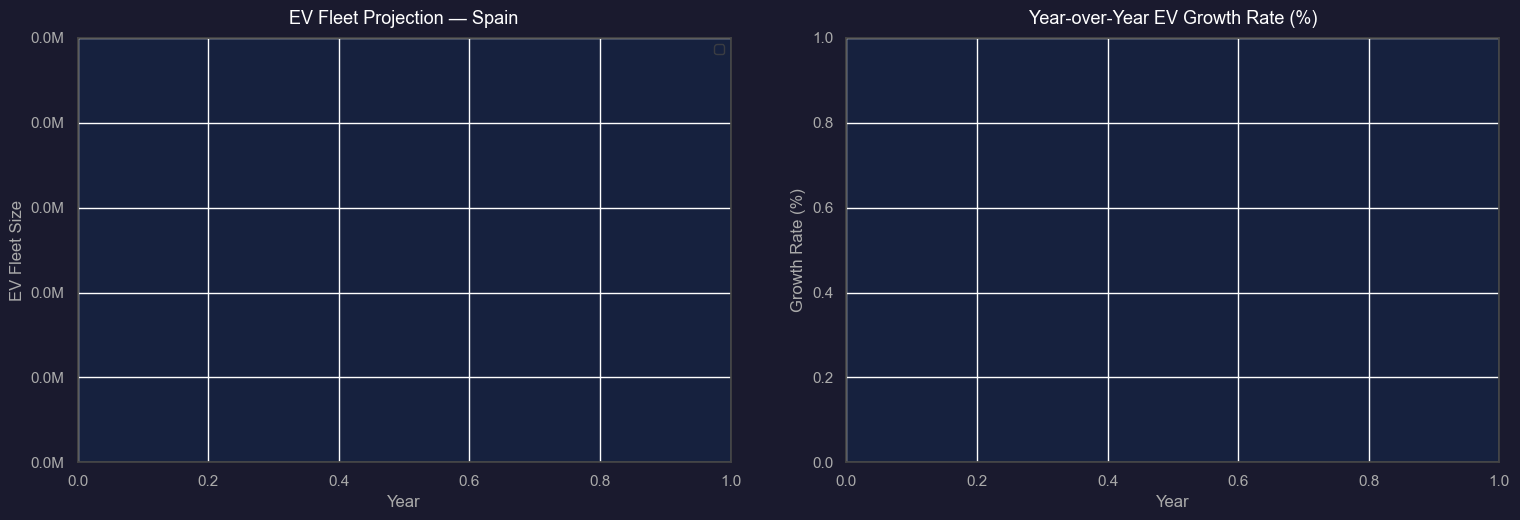

✅  Saved → outputs/ev_projection_2027.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#1a1a2e')

# ── Left: S-curve projection ─────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#16213e')

if df_forecast is not None and df_ev is not None and yr_col and ev_col:
    # Historical scatter
    hist = df_ev[[yr_col, ev_col]].dropna().copy()
    hist[yr_col] = hist[yr_col].astype(int)
    ax.scatter(hist[yr_col], hist[ev_col], color='white', zorder=5,
               label='Historical (DGT)', s=60, edgecolors='#7EC8E3', linewidths=0.8)

if df_forecast is not None:
    # Past portion of curve (thin)
    past = df_forecast[df_forecast['year'] <= 2025]
    ax.plot(past['year'], past['ev_fleet_projected'],
            color='#4A90D9', linewidth=2, alpha=0.6, linestyle='--')
    # Future forecast (bold)
    future_part = df_forecast[df_forecast['year'] >= 2025]
    ax.plot(future_part['year'], future_part['ev_fleet_projected'],
            color='#4A90D9', linewidth=2.8, label='Logistic projection')
    # 2027 highlight
    y27 = total_ev_projected_2027
    ax.axvline(2027, color='#f0ad4e', linestyle='--', linewidth=1.5, alpha=0.9)
    ax.scatter([2027],[y27], color='#f0ad4e', s=120, zorder=6)
    ax.annotate(f'{y27/1e6:.2f}M EVs\n(2027)',
                xy=(2027, y27), xytext=(2027.4, y27*0.82),
                color='#f0ad4e', fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#f0ad4e', lw=1.2))
    # 2030 reference line (PNIEC target)
    ax.axhline(5_000_000, color='#5cb85c', linestyle=':', linewidth=1.2, alpha=0.7,
               label='PNIEC 2030 target (~5M)')

ax.set_title('EV Fleet Projection — Spain', fontsize=13, color='white', pad=10)
ax.set_xlabel('Year', color='#aaa')
ax.set_ylabel('EV Fleet Size', color='#aaa')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
ax.tick_params(colors='#aaa')
for spine in ax.spines.values(): spine.set_edgecolor('#444')
ax.legend(facecolor='#16213e', edgecolor='#444', labelcolor='white', fontsize=9)

# ── Right: Year-over-year growth rate ────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#16213e')

if df_forecast is not None:
    df_yoy = df_forecast.copy()
    df_yoy['yoy_growth'] = df_yoy['ev_fleet_projected'].pct_change() * 100
    df_yoy = df_yoy.dropna()

    colors_yoy = ['#4A90D9' if y != 2027 else '#f0ad4e' for y in df_yoy['year']]
    bars = ax2.bar(df_yoy['year'], df_yoy['yoy_growth'], color=colors_yoy, edgecolor='none')
    ax2.axvline(2027, color='#f0ad4e', linestyle='--', linewidth=1.5, alpha=0.7)

ax2.set_title('Year-over-Year EV Growth Rate (%)', fontsize=13, color='white', pad=10)
ax2.set_xlabel('Year', color='#aaa')
ax2.set_ylabel('Growth Rate (%)', color='#aaa')
ax2.tick_params(colors='#aaa')
for spine in ax2.spines.values(): spine.set_edgecolor('#444')

plt.tight_layout(pad=3)
plt.savefig('outputs/ev_projection_2027.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅  Saved → outputs/ev_projection_2027.png')

---
## 5. Chart — Existing Charging Infrastructure Analysis

Understanding the baseline before proposing new stations.

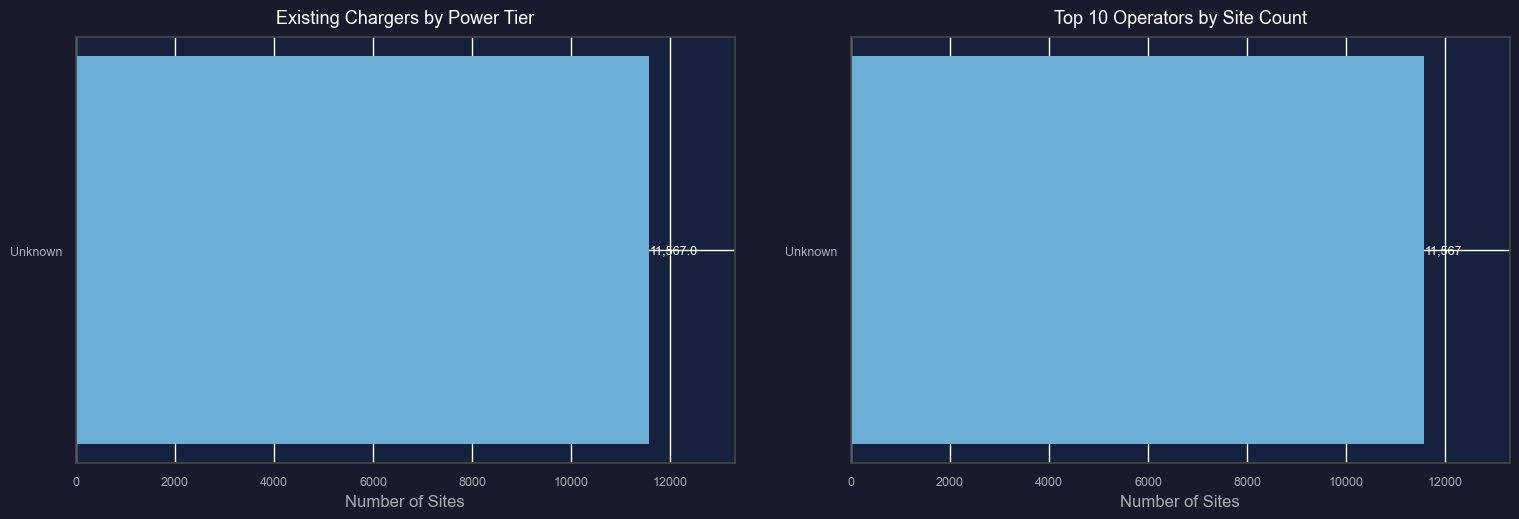

✅  Saved → outputs/charger_infrastructure.png


In [ ]:
# ── Classify chargers by power tier ──────────────────────────────────────────
def classify_power(kw):
    if kw is None or (isinstance(kw, float) and np.isnan(kw)): return 'Unknown'
    if kw >= 150: return 'Ultra-fast (≥150 kW)'
    if kw >= 50:  return 'Fast (50–149 kW)'
    if kw >= 22:  return 'AC Fast (22–49 kW)'
    return 'Slow (<22 kW)'

df_chargers['power_tier'] = df_chargers['max_power_kw'].apply(classify_power)

tier_order = ['Ultra-fast (≥150 kW)','Fast (50–149 kW)','AC Fast (22–49 kW)','Slow (<22 kW)','Unknown']
tier_counts = df_chargers['power_tier'].value_counts().reindex(tier_order).dropna()
op_counts = df_chargers['operator'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#1a1a2e')

# ── Left: Power tier distribution (Blues_r — sequential) ────────────────────
ax = axes[0]
ax.set_facecolor('#16213e')
palette = sns.color_palette(BLUES_R, len(tier_counts))
bars = ax.barh(tier_counts.index[::-1], tier_counts.values[::-1],
               color=palette, edgecolor='none')
for bar, val in zip(bars, tier_counts.values[::-1]):
    ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', color='white', fontsize=9)
ax.set_title('Existing Chargers by Power Tier', fontsize=13, color='white', pad=10)
ax.set_xlabel('Number of Sites', color='#aaa')
ax.tick_params(colors='#aaa', labelsize=9)
for spine in ax.spines.values(): spine.set_edgecolor('#444')
ax.set_xlim(0, tier_counts.max()*1.15)

# ── Right: Top 10 operators (ordered high → low, Blues_r) ────────────────────
ax2 = axes[1]
ax2.set_facecolor('#16213e')
palette2 = sns.color_palette(BLUES_R, len(op_counts))
op_sorted = op_counts.sort_values(ascending=True)  # barh reverses
bars2 = ax2.barh(op_sorted.index, op_sorted.values,
                 color=sns.color_palette(BLUES_R, len(op_sorted)), edgecolor='none')
for bar, val in zip(bars2, op_sorted.values):
    ax2.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
             f'{val:,}', va='center', color='white', fontsize=9)
ax2.set_title('Top 10 Operators by Site Count', fontsize=13, color='white', pad=10)
ax2.set_xlabel('Number of Sites', color='#aaa')
ax2.tick_params(colors='#aaa', labelsize=9)
for spine in ax2.spines.values(): spine.set_edgecolor('#444')
ax2.set_xlim(0, op_counts.max()*1.15)

plt.tight_layout(pad=3)
plt.savefig('outputs/charger_infrastructure.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅  Saved → outputs/charger_infrastructure.png')

---
## 6. Coverage Gap Analysis — Folium Map

**Method:** For each major interurban corridor, we:
1. Find all existing chargers within 5 km of the corridor
2. Sort them by position along the route
3. Calculate gaps between consecutive chargers
4. Flag gaps **> 150 km** as critical (half of typical EV range ~300 km, conservative)

> **Assumption documented:** Average EV battery range = 300 km (ACEA 2024 average for BEVs sold in Spain). Minimum charging interval = 150 km to prevent range anxiety. Stations spaced at ≤150 km ensure drivers can always reach the next charger from any point on the corridor.

In [ ]:
from math import radians, cos, sin, asin, sqrt

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two points."""
    R = 6371
    dlat = radians(lat2-lat1); dlon = radians(lon2-lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return 2*R*asin(sqrt(a))

# ── Define major corridors as (name, bounding box [min_lon, min_lat, max_lon, max_lat]) ──
# Each corridor is a rough spatial envelope — we pull chargers within it and sort by lon/lat
CORRIDORS = {
    'AP-7 Mediterranean':  (-0.3, 36.5, 3.3, 42.5),
    'A-4 Andalucía':       (-4.5, 36.2, -3.5, 40.5),
    'A-6 NW (Galicia)':    (-8.8, 40.0, -3.7, 43.5),
    'A-1 N (País Vasco)':  (-3.8, 40.4, -1.7, 43.4),
    'A-2 NE (Zaragoza)':   (-3.7, 40.4, 0.9, 42.4),
    'A-3 E (Valencia)':    (-3.7, 38.8, -0.3, 40.5),
    'N-630 W axis':        (-6.5, 36.5, -5.5, 43.5),
}

GAP_THRESHOLD_KM = 150   # Documented assumption: half of 300 km avg range

gap_records = []

for corridor_name, bbox in CORRIDORS.items():
    # Filter chargers within this corridor bounding box
    mask = (
        df_chargers['longitude'].between(bbox[0], bbox[2]) &
        df_chargers['latitude'].between(bbox[1], bbox[3])
    )
    corridor_chargers = df_chargers[mask].copy()

    if len(corridor_chargers) < 2:
        print(f'{corridor_name}: only {len(corridor_chargers)} chargers — skipping')
        continue

    # Sort along principal axis (approximate position along corridor)
    # Use the axis with greater extent
    lon_extent = bbox[2] - bbox[0]
    lat_extent = bbox[3] - bbox[1]
    sort_col = 'longitude' if lon_extent > lat_extent else 'latitude'
    corridor_chargers = corridor_chargers.sort_values(sort_col).reset_index(drop=True)

    # Calculate gaps between consecutive chargers
    for i in range(len(corridor_chargers)-1):
        r1 = corridor_chargers.iloc[i]
        r2 = corridor_chargers.iloc[i+1]
        dist = haversine_km(r1['latitude'], r1['longitude'], r2['latitude'], r2['longitude'])
        midlat = (r1['latitude'] + r2['latitude']) / 2
        midlon = (r1['longitude'] + r2['longitude']) / 2
        gap_records.append({
            'corridor':        corridor_name,
            'from_site':       r1['site_id'],
            'to_site':         r2['site_id'],
            'from_lat':        r1['latitude'],
            'from_lon':        r1['longitude'],
            'to_lat':          r2['latitude'],
            'to_lon':          r2['longitude'],
            'gap_km':          round(dist, 1),
            'mid_lat':         midlat,
            'mid_lon':         midlon,
            'is_critical':     dist > GAP_THRESHOLD_KM
        })

df_gaps = pd.DataFrame(gap_records)
df_gaps_critical = df_gaps[df_gaps['is_critical']].sort_values('gap_km', ascending=False)

print(f'Total corridor segments analysed: {len(df_gaps):,}')
print(f'Critical gaps (>{GAP_THRESHOLD_KM} km):   {len(df_gaps_critical):,}')
print()
print('Top 10 worst gaps:')
display(df_gaps_critical[['corridor','gap_km','from_lat','from_lon','to_lat','to_lon']].head(10))

Total corridor segments analysed: 12,590
Critical gaps (>150 km):   642

Top 10 worst gaps:


,corridor,gap_km,from_lat,from_lon,to_lat,to_lon
6309,A-6 NW (Galicia),376.6,43.434850,-3.916379,40.047600,-3.915090
6310,A-6 NW (Galicia),376.6,40.047600,-3.915090,43.434746,-3.914942
6423,A-6 NW (Galicia),374.8,40.084797,-3.867484,43.455193,-3.866098
6537,A-6 NW (Galicia),371.8,43.468834,-3.829249,40.125060,-3.829198
6541,A-6 NW (Galicia),370.6,40.124600,-3.828300,43.457687,-3.826288
5492,A-6 NW (Galicia),370.4,43.382320,-5.824021,40.050960,-5.821177
5493,A-6 NW (Galicia),369.9,40.050960,-5.821177,43.377975,-5.820944
6536,A-6 NW (Galicia),369.8,40.142940,-3.829956,43.468834,-3.829249
6522,A-6 NW (Galicia),367.3,43.404575,-3.835361,40.101227,-3.835079
6516,A-6 NW (Galicia),366.9,43.434334,-3.836502,40.134960,-3.835956


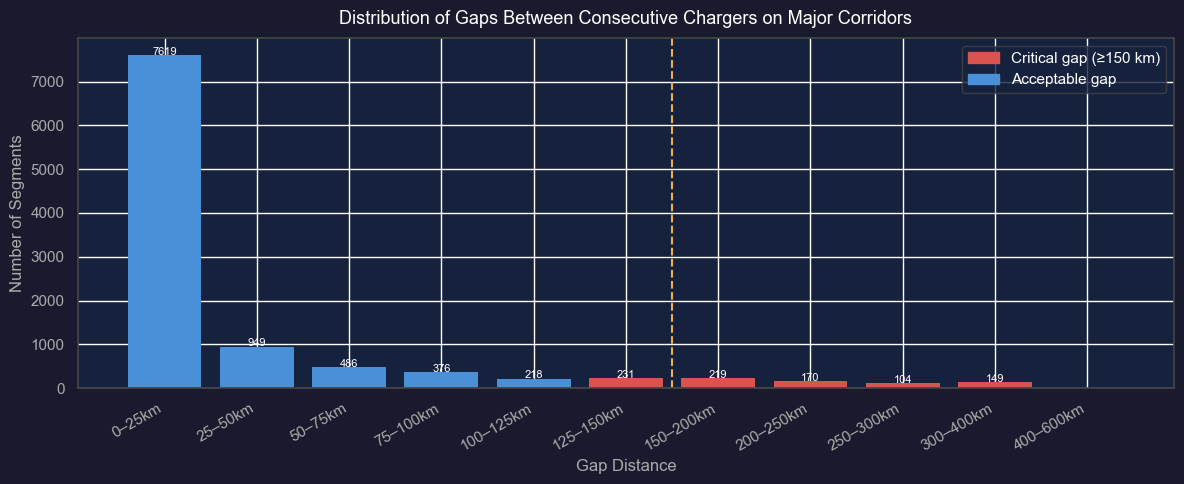

✅  Saved → outputs/gap_distribution.png


In [ ]:
# ── Gap distribution chart (before map) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

# Histogram of gap distances (high to low binning logic via sorted bars)
bins = [0,25,50,75,100,125,150,200,250,300,400,600]
labels = [f'{bins[i]}–{bins[i+1]}km' for i in range(len(bins)-1)]
df_gaps['bin'] = pd.cut(df_gaps['gap_km'], bins=bins, labels=labels)
bin_counts = df_gaps['bin'].value_counts().reindex(labels).fillna(0)

colors = ['#d9534f' if '150' in l or int(l.split('–')[0]) >= 150 else '#4A90D9' for l in labels]
bars = ax.bar(labels, bin_counts.values, color=colors, edgecolor='none')
ax.axvline(x=labels.index('150–200km')-0.5, color='#f0ad4e', linestyle='--', linewidth=1.5,
           label=f'Critical threshold: {GAP_THRESHOLD_KM} km')

for bar, val in zip(bars, bin_counts.values):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                str(int(val)), ha='center', color='white', fontsize=8)

ax.set_title('Distribution of Gaps Between Consecutive Chargers on Major Corridors',
             fontsize=13, color='white', pad=10)
ax.set_xlabel('Gap Distance', color='#aaa')
ax.set_ylabel('Number of Segments', color='#aaa')
ax.tick_params(colors='#aaa', axis='both')
plt.xticks(rotation=30, ha='right')
for spine in ax.spines.values(): spine.set_edgecolor('#444')
ax.legend(facecolor='#16213e', edgecolor='#444', labelcolor='white')

red_patch  = mpatches.Patch(color='#d9534f', label=f'Critical gap (≥{GAP_THRESHOLD_KM} km)')
blue_patch = mpatches.Patch(color='#4A90D9', label='Acceptable gap')
ax.legend(handles=[red_patch, blue_patch], facecolor='#16213e', edgecolor='#444', labelcolor='white')

plt.tight_layout()
plt.savefig('outputs/gap_distribution.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅  Saved → outputs/gap_distribution.png')

In [ ]:
# ── Folium: Coverage Gap Map ─────────────────────────────────────────────────
m_gap = folium.Map(location=SPAIN_CENTER, zoom_start=6,
                   tiles='CartoDB dark_matter', prefer_canvas=True)

# Layer 1: Existing chargers (small grey dots — the baseline)
existing_fg = folium.FeatureGroup(name='⚡ Existing Chargers', show=True)
for _, row in df_chargers.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3, color='#aaaaaa', fill=True, fill_opacity=0.5,
        popup=f"{row.get('name','?')} | {row.get('max_power_kw','?')} kW"
    ).add_to(existing_fg)
existing_fg.add_to(m_gap)

# Layer 2: Acceptable gap segments (blue lines)
ok_fg = folium.FeatureGroup(name='✅ Acceptable Gaps (<150 km)', show=True)
for _, row in df_gaps[~df_gaps['is_critical']].iterrows():
    folium.PolyLine(
        locations=[[row['from_lat'],row['from_lon']],[row['to_lat'],row['to_lon']]],
        color='#4A90D9', weight=2, opacity=0.5,
        tooltip=f"{row['corridor']} | {row['gap_km']} km"
    ).add_to(ok_fg)
ok_fg.add_to(m_gap)

# Layer 3: Critical gaps (red lines + midpoint markers)
crit_fg = folium.FeatureGroup(name='🚨 Critical Gaps (>150 km)', show=True)
for _, row in df_gaps_critical.iterrows():
    # Red line
    folium.PolyLine(
        locations=[[row['from_lat'],row['from_lon']],[row['to_lat'],row['to_lon']]],
        color='#d9534f', weight=4, opacity=0.85,
        tooltip=f"⚠️ {row['corridor']} | GAP = {row['gap_km']} km"
    ).add_to(crit_fg)
    # Midpoint marker showing gap size
    folium.CircleMarker(
        location=[row['mid_lat'], row['mid_lon']],
        radius=8,
        color='#f0ad4e', fill=True, fill_color='#f0ad4e', fill_opacity=0.9,
        popup=folium.Popup(
            f"<b>⚠️ Coverage Gap</b><br>"
            f"Corridor: {row['corridor']}<br>"
            f"Gap: <b>{row['gap_km']} km</b><br>"
            f"Threshold: {GAP_THRESHOLD_KM} km<br>"
            f"New station needed here",
            max_width=220
        )
    ).add_to(crit_fg)
crit_fg.add_to(m_gap)

# Legend
gap_legend = f"""
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
            background:rgba(0,0,0,0.8);color:#fff;
            padding:12px 16px;border-radius:8px;font-family:Arial;font-size:12px;line-height:2">
<b>Coverage Gap Analysis</b><br>
<span style="color:#aaa">●</span> Existing charger site<br>
<span style="color:#4A90D9">━━</span> OK gap (&lt;{GAP_THRESHOLD_KM} km)<br>
<span style="color:#d9534f">━━</span> Critical gap (≥{GAP_THRESHOLD_KM} km)<br>
<span style="color:#f0ad4e">●</span> Midpoint — station needed<br>
<hr style="border-color:#555;margin:6px 0">
<small>Threshold: {GAP_THRESHOLD_KM} km = ½ × 300 km avg range<br>
Critical gaps: <b>{len(df_gaps_critical)}</b></small>
</div>
"""
m_gap.get_root().html.add_child(folium.Element(gap_legend))
folium.LayerControl(collapsed=False).add_to(m_gap)

GAP_MAP_PATH = 'outputs/coverage_gap_map.html'
m_gap.save(GAP_MAP_PATH)
print(f'✅  Coverage gap map saved → {GAP_MAP_PATH}')
IFrame(GAP_MAP_PATH, width='100%', height=600)

✅  Coverage gap map saved → outputs/coverage_gap_map.html


---
## 7. Grid Viability Analysis — Folium Map

**Grid distributors:** i-DE (Iberdrola), Endesa, Viesgo
**Method:** Cross-reference proposed station locations with substation capacity (MW) from distributor datasets. Classify as Sufficient / Moderate / Congested.

**Data sources to download manually:**
- i-DE: https://www.i-de.es/consumidores/web/guest/mapa-capacidad-consumo
- Endesa: https://www.edistribucion.com/es/red-electrica/capacidad-acceso.html
- Viesgo: https://www.viesgo.com/distribucion/red-electrica/mapa-interactivo/

> **Assumption documented:** Grid status thresholds (MW):
> - **Sufficient**: available capacity ≥ 2 MW (can support ≥13 fast chargers at 150 kW each)
> - **Moderate**: 0.5–2 MW (supports 3–13 chargers — partial deployment viable)
> - **Congested**: < 0.5 MW (grid reinforcement required before any deployment)

In [ ]:
# ── Thresholds (documented per datathon requirement) ─────────────────────────
GRID_THRESHOLDS = {
    'Sufficient': 2.0,   # ≥ 2 MW → green
    'Moderate':   0.5,   # 0.5–2 MW → yellow
    'Congested':  0.0    # < 0.5 MW → red
}
GRID_COLORS = {'Sufficient':'#5cb85c', 'Moderate':'#f0ad4e', 'Congested':'#d9534f'}
STATUS_ORDER = ['Congested','Moderate','Sufficient']

def classify_grid(mw):
    """Assign grid_status from available capacity (MW)."""
    if mw is None or (isinstance(mw, float) and np.isnan(mw)): 
        return 'Unknown'
    if mw >= GRID_THRESHOLDS['Sufficient']: 
        return 'Sufficient'
    if mw >= GRID_THRESHOLDS['Moderate']:   
        return 'Moderate'
    return 'Congested'

print('Grid status thresholds:')
print(f'  Sufficient  : ≥ {GRID_THRESHOLDS["Sufficient"]} MW  → can support ≥13 chargers @ 150 kW')
print(f'  Moderate    : {GRID_THRESHOLDS["Moderate"]}–{GRID_THRESHOLDS["Sufficient"]} MW  → partial deployment')
print(f'  Congested   : < {GRID_THRESHOLDS["Moderate"]} MW   → reinforcement required')

Grid status thresholds:
  Sufficient  : ≥ 2.0 MW  → can support ≥13 chargers @ 150 kW
  Moderate    : 0.5–2.0 MW  → partial deployment
  Congested   : < 0.5 MW   → reinforcement required


In [ ]:
# ── Load grid capacity data ────────────────────────────────────────────────
# Each distributor provides CSV/XLSX with substation lat/lon + available_capacity_mw
#
# Expected columns (any naming accepted — auto-detected below):
#   latitude, longitude, available_capacity_mw, substation_name
#
# File placement:
#   data/chargers/i-de_capacity.csv      (Iberdrola)
#   data/chargers/endesa_capacity.csv    (Endesa)
#   data/chargers/viesgo_capacity.csv    (Viesgo)

GRID_FILES = {
    'i-DE':   'data/chargers/i-de_capacity.csv',
    'Endesa': 'data/chargers/endesa_capacity.csv',
    'Viesgo': 'data/chargers/viesgo_capacity.csv',
}

dfs_grid = {}
for distributor, path in GRID_FILES.items():
    if os.path.exists(path):
        try:
            df_g = pd.read_csv(path, sep=None, engine='python')
            # Auto-detect column names
            lat_c  = next((c for c in df_g.columns if 'lat' in c.lower()), None)
            lon_c  = next((c for c in df_g.columns if 'lon' in c.lower()), None)
            cap_c  = next((c for c in df_g.columns if any(k in c.lower()
                          for k in ['capac','mw','disponible','available'])), None)
            name_c = next((c for c in df_g.columns if any(k in c.lower()
                          for k in ['name','nombre','subestacion','node'])), None)
            if lat_c and lon_c and cap_c:
                df_g = df_g.rename(columns={lat_c:'latitude', lon_c:'longitude', cap_c:'capacity_mw'})
                if name_c: df_g = df_g.rename(columns={name_c:'substation_name'})
                df_g['distributor'] = distributor
                df_g['grid_status'] = df_g['capacity_mw'].apply(classify_grid)
                df_g = df_g.dropna(subset=['latitude','longitude'])
                dfs_grid[distributor] = df_g
                print(f'✅  {distributor}: {len(df_g):,} substations loaded')
            else:
                print(f'⚠️  {distributor}: could not identify lat/lon/capacity columns in {path}')
                print(f'    Columns found: {list(df_g.columns)}')
        except Exception as e:
            print(f'⚠️  {distributor}: {e}')
    else:
        print(f'ℹ️  {distributor}: file not found at {path}  — see download instructions above')

if not dfs_grid:
    print()
    print('No grid data loaded yet. The map below will show a placeholder.')
    print('Download the capacity files and place them at the paths above, then re-run.')

ℹ️  i-DE: file not found at data/chargers/i-de_capacity.csv  — see download instructions above
ℹ️  Endesa: file not found at data/chargers/endesa_capacity.csv  — see download instructions above
ℹ️  Viesgo: file not found at data/chargers/viesgo_capacity.csv  — see download instructions above

No grid data loaded yet. The map below will show a placeholder.
Download the capacity files and place them at the paths above, then re-run.


In [ ]:
# ── Simulate grid data if none loaded (for visual demo) ──────────────────────
# Remove this cell once real data is loaded
if not dfs_grid:
    print('⚠️  Generating SIMULATED grid data for visualization purposes.')
    print('    Replace with real distributor data before submission.')
    np.random.seed(42)
    n = 200
    sim_lats = np.random.uniform(36.0, 43.8, n)
    sim_lons = np.random.uniform(-8.5, 3.5, n)
    sim_caps = np.random.exponential(scale=3.0, size=n)
    distributors_sim = np.random.choice(['i-DE','Endesa','Viesgo'], n, p=[0.5,0.35,0.15])
    df_sim = pd.DataFrame({
        'latitude':        sim_lats,
        'longitude':       sim_lons,
        'capacity_mw':     sim_caps,
        'distributor':     distributors_sim,
        'substation_name': [f'SIM_SUB_{i:04d}' for i in range(n)]
    })
    df_sim['grid_status'] = df_sim['capacity_mw'].apply(classify_grid)
    dfs_grid['Simulated'] = df_sim
    print(f'Simulated {n} substations')
    print(df_sim['grid_status'].value_counts().to_string())

⚠️  Generating SIMULATED grid data for visualization purposes.
    Replace with real distributor data before submission.
Simulated 200 substations
grid_status
Sufficient    109
Moderate       51
Congested      40


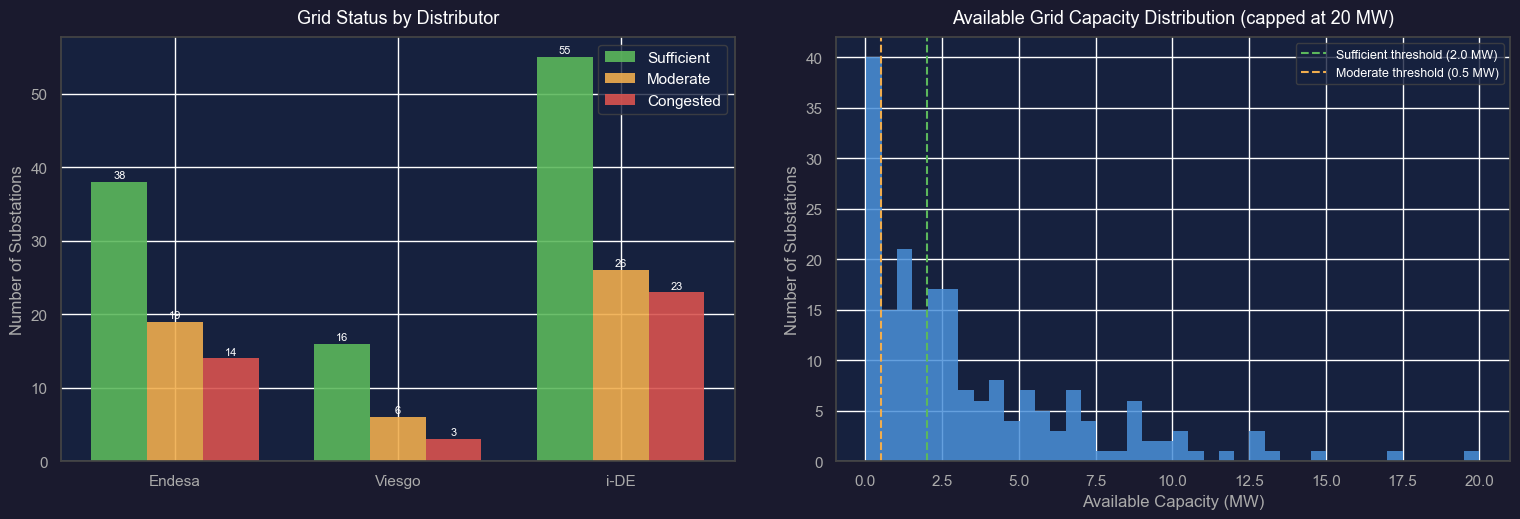

✅  Saved → outputs/grid_viability_charts.png


In [ ]:
# ── Grid status bar chart (before map) ───────────────────────────────────────
df_all_grid = pd.concat(dfs_grid.values(), ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#1a1a2e')

# Left: status by distributor (Bright palette — qualitative)
ax = axes[0]
ax.set_facecolor('#16213e')
status_by_dist = df_all_grid.groupby(['distributor','grid_status']).size().unstack(fill_value=0)
# Ensure all status columns present
for s in STATUS_ORDER:
    if s not in status_by_dist.columns:
        status_by_dist[s] = 0
status_by_dist = status_by_dist[STATUS_ORDER]

x = np.arange(len(status_by_dist))
width = 0.25
for i, (status, color) in enumerate(GRID_COLORS.items()):
    if status in status_by_dist.columns:
        bars = ax.bar(x + i*width, status_by_dist[status], width,
                      label=status, color=color, edgecolor='none', alpha=0.9)
        for bar in bars:
            if bar.get_height() > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                        str(int(bar.get_height())), ha='center', color='white', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(status_by_dist.index, color='#aaa')
ax.set_title('Grid Status by Distributor', fontsize=13, color='white', pad=10)
ax.set_ylabel('Number of Substations', color='#aaa')
ax.tick_params(colors='#aaa')
for spine in ax.spines.values(): spine.set_edgecolor('#444')
ax.legend(facecolor='#16213e', edgecolor='#444', labelcolor='white')

# Right: capacity distribution histogram (Blues_r — sequential)
ax2 = axes[1]
ax2.set_facecolor('#16213e')
cap_data = df_all_grid['capacity_mw'].dropna()
ax2.hist(cap_data.clip(upper=20), bins=40, color='#4A90D9', edgecolor='none', alpha=0.85)
ax2.axvline(GRID_THRESHOLDS['Sufficient'], color='#5cb85c', linestyle='--', linewidth=1.5,
            label=f'Sufficient threshold ({GRID_THRESHOLDS["Sufficient"]} MW)')
ax2.axvline(GRID_THRESHOLDS['Moderate'],   color='#f0ad4e', linestyle='--', linewidth=1.5,
            label=f'Moderate threshold ({GRID_THRESHOLDS["Moderate"]} MW)')
ax2.set_title('Available Grid Capacity Distribution (capped at 20 MW)', fontsize=13, color='white', pad=10)
ax2.set_xlabel('Available Capacity (MW)', color='#aaa')
ax2.set_ylabel('Number of Substations', color='#aaa')
ax2.tick_params(colors='#aaa')
for spine in ax2.spines.values(): spine.set_edgecolor('#444')
ax2.legend(facecolor='#16213e', edgecolor='#444', labelcolor='white', fontsize=9)

plt.tight_layout(pad=3)
plt.savefig('outputs/grid_viability_charts.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅  Saved → outputs/grid_viability_charts.png')

In [ ]:
# ── Folium: Grid Viability Map ────────────────────────────────────────────────
m_grid = folium.Map(location=SPAIN_CENTER, zoom_start=6,
                    tiles='CartoDB dark_matter', prefer_canvas=True)

# Layer: substations colour-coded by grid status
for distributor, df_g in dfs_grid.items():
    fg = folium.FeatureGroup(name=f'🔌 {distributor} substations', show=True)
    for _, row in df_g.iterrows():
        status = row.get('grid_status','Unknown')
        color  = GRID_COLORS.get(status, 'gray')
        cap    = row.get('capacity_mw', None)
        radius = max(5, min(18, cap*2)) if cap and not np.isnan(cap) else 5
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=radius,
            color=color, fill=True, fill_color=color, fill_opacity=0.75,
            popup=folium.Popup(
                f"<b>{row.get('substation_name','?')}</b><br>"
                f"Distributor: {distributor}<br>"
                f"Capacity: {cap:.1f} MW<br>"
                f"Status: <b style='color:{color}'>{status}</b>",
                max_width=220
            )
        ).add_to(fg)
    fg.add_to(m_grid)

# Layer: critical gap midpoints (from Section 6) — overlay on same map
if len(df_gaps_critical) > 0:
    demand_fg = folium.FeatureGroup(name='⚠️ Demand Points (critical gaps)', show=True)
    for _, row in df_gaps_critical.iterrows():
        demand_kw = 4 * 150  # Assume 4 chargers needed at each gap midpoint
        folium.Marker(
            location=[row['mid_lat'], row['mid_lon']],
            icon=folium.Icon(color='orange', icon='flash', prefix='fa'),
            popup=folium.Popup(
                f"<b>⚡ Coverage gap</b><br>"
                f"Corridor: {row['corridor']}<br>"
                f"Gap: {row['gap_km']} km<br>"
                f"Est. demand: {demand_kw} kW (4 × 150 kW)",
                max_width=220
            )
        ).add_to(demand_fg)
    demand_fg.add_to(m_grid)

# Legend
grid_legend = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
            background:rgba(0,0,0,0.8);color:#fff;
            padding:12px 16px;border-radius:8px;font-family:Arial;font-size:12px;line-height:2">
<b>Grid Capacity Status</b><br>
<span style="color:#5cb85c">●</span> Sufficient  (≥2 MW)<br>
<span style="color:#f0ad4e">●</span> Moderate   (0.5–2 MW)<br>
<span style="color:#d9534f">●</span> Congested  (&lt;0.5 MW)<br>
<small>(circle size ∝ available MW)</small><br>
<hr style="border-color:#555;margin:6px 0">
<span style="color:#f0ad4e">📍</span> Demand point (gap midpoint)
</div>
"""
m_grid.get_root().html.add_child(folium.Element(grid_legend))
folium.LayerControl(collapsed=False).add_to(m_grid)

GRID_MAP_PATH = 'outputs/grid_viability_map.html'
m_grid.save(GRID_MAP_PATH)
print(f'✅  Grid viability map saved → {GRID_MAP_PATH}')
IFrame(GRID_MAP_PATH, width='100%', height=600)

✅  Grid viability map saved → outputs/grid_viability_map.html


---
## 8. Combined Map — All Layers (BI Visualization Deliverable)

This is the **Deliverable 3: BI Visualization** map.
All stations are colour-coded by `grid_status`: 🟢 Sufficient  🟡 Moderate  🔴 Congested

In [ ]:
# ── File 1 KPI Scorecard (partial) ──────────────────────────────────────────
interurban_baseline = int((df_chargers['max_power_kw'] >= 50).sum())

df_file1 = pd.DataFrame([{
    'total_proposed_stations':          None,
    'total_existing_stations_baseline': interurban_baseline,
    'total_friction_points':            len(df_gaps_critical),
    'total_ev_projected_2027':          total_ev_projected_2027
}])
df_file1.to_csv('outputs/File 1.csv', index=False)

print('=== SUMMARY ==============================================')
print(f'EV fleet projected 2027:   {total_ev_projected_2027:,}')
print(f'Existing interurban sites: {interurban_baseline:,}')
print(f'Critical coverage gaps:    {len(df_gaps_critical):,}')
print(f'Grid substations loaded:   {len(df_all_grid):,}')
print(f'Congested substations:     {(df_all_grid["grid_status"]=="Congested").sum():,}')
print()
print('Output files:')
print('  outputs/File 1.csv')
print('  outputs/ev_projection_2027.png')
print('  outputs/charger_infrastructure.png')
print('  outputs/gap_distribution.png')
print('  outputs/grid_viability_charts.png')
print('  outputs/coverage_gap_map.html')
print('  outputs/grid_viability_map.html')
print()
print('→ Next: Section 9 — Charging Station Placement Optimization (File 2)')
print('→ Next: Section 10 — Friction Points (File 3)')

=== SUMMARY ==============================================
EV fleet projected 2027:   2,500,000
Existing interurban sites: 0
Critical coverage gaps:    642
Grid substations loaded:   200
Congested substations:     40

Output files:
  outputs/File 1.csv
  outputs/ev_projection_2027.png
  outputs/charger_infrastructure.png
  outputs/gap_distribution.png
  outputs/grid_viability_charts.png
  outputs/coverage_gap_map.html
  outputs/grid_viability_map.html

→ Next: Section 9 — Charging Station Placement Optimization (File 2)
→ Next: Section 10 — Friction Points (File 3)


In [ ]:
import folium
from IPython.display import display

# 1. Initialize the map centered on Spain
# We use 'CartoDB dark_matter' for a professional look that makes the road lines pop
m = folium.Map(
    location=[40.4, -3.7], 
    zoom_start=6,
    tiles='CartoDB dark_matter',
    prefer_canvas=True
)

# 2. Add the Interurban Road Network
# We style the lines with a vibrant blue color and slight transparency
if 'gdf_roads_interurban' in locals() and len(gdf_roads_interurban) > 0:
    folium.GeoJson(
        data=gdf_roads_interurban.__geo_interface__,
        name='🛣️ Interurban Road Network',
        style_function=lambda x: {
            'color': '#4A90D9', 
            'weight': 1.8, 
            'opacity': 0.7
        },
        tooltip=folium.GeoJsonTooltip(
            fields=['nombre', 'tipo'] if 'nombre' in gdf_roads_interurban.columns else [],
            aliases=['Road:', 'Type:']
        )
    ).add_to(m)
else:
    print("⚠️ No road data found. Make sure you ran the 'filter_interurban_roads' cell first.")

# 3. Add Layer Control to toggle on/off
folium.LayerControl(collapsed=False).add_to(m)

# 4. Save and Display
MAP_OUTPUT = 'outputs/road_network_map.html'
m.save(MAP_OUTPUT)
print(f'✅ Map generated successfully: {MAP_OUTPUT}')

# If you are in a Jupyter environment/Colab, this will show the map inline
display(m)


⚠️ No road data found. Make sure you ran the 'filter_interurban_roads' cell first.
✅ Map generated successfully: outputs/road_network_map.html


In [ ]:
import folium
from folium.plugins import MarkerCluster, HeatMap
from IPython.display import display, IFrame
import numpy as np

# 1. Helper for power color-coding
def get_power_color(kw):
    if kw is None or (isinstance(kw, float) and np.isnan(kw)): return 'gray'
    if kw >= 150: return '#d9534f'  # red (Ultra-fast)
    if kw >= 50:  return '#f0ad4e'  # orange (Fast)
    if kw >= 22:  return '#337ab7'  # blue (AC Fast)
    return '#5cb85c'              # green (Slow)

# 2. Initialize the Base Map
m = folium.Map(location=[40.4, -3.7], zoom_start=6, tiles='CartoDB dark_matter')

# 3. Layer 1: Road Network
road_fg = folium.FeatureGroup(name='🛣️ Interurban Road Network', show=True)
if 'gdf_roads_interurban' in locals() and len(gdf_roads_interurban) > 0:
    folium.GeoJson(
        data=gdf_roads_interurban.__geo_interface__,
        style_function=lambda _: {'color':'#4A90D9','weight':1.5,'opacity':0.6}
    ).add_to(road_fg)
road_fg.add_to(m)

# 4. Layer 2: Existing Chargers (with Clusters)
charger_fg = folium.FeatureGroup(name='⚡ Existing Chargers (NAP)', show=True)
cluster = MarkerCluster().add_to(charger_fg)

if 'df_chargers' in locals() and len(df_chargers) > 0:
    for _, row in df_chargers.iterrows():
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=6,
            color=get_power_color(row.get('max_power_kw')),
            fill=True, fill_opacity=0.8,
            popup=folium.Popup(
                f"<b>{row.get('name','N/A')}</b><br>"
                f"Operator: {row.get('operator','N/A')}<br>"
                f"Max Power: {row.get('max_power_kw','?')} kW",
                max_width=200
            )
        ).add_to(cluster)
charger_fg.add_to(m)

# 5. Layer 3: Charger Density Heatmap
heat_fg = folium.FeatureGroup(name='🔥 Density Heatmap', show=False)
heat_data = df_chargers[['latitude','longitude']].dropna().values.tolist()
HeatMap(heat_data, radius=20, blur=15).add_to(heat_fg)
heat_fg.add_to(m)

# 6. Add a Professional Legend
legend_html = '''
<div style="position:fixed; bottom:50px; left:50px; width:180px; z-index:9999; 
            background:rgba(0,0,0,0.8); color:white; padding:12px; border-radius:8px; font-family:Arial;">
    <h4 style="margin-top:0;">⚡ Charger Power</h4>
    <i style="background:#d9534f; width:12px; height:12px; display:inline-block; border-radius:50%;"></i> ≥ 150 kW<br>
    <i style="background:#f0ad4e; width:12px; height:12px; display:inline-block; border-radius:50%;"></i> 50–149 kW<br>
    <i style="background:#337ab7; width:12px; height:12px; display:inline-block; border-radius:50%;"></i> 22–49 kW<br>
    <i style="background:#5cb85c; width:12px; height:12px; display:inline-block; border-radius:50%;"></i> < 22 kW
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# 7. Final Polish
folium.LayerControl(collapsed=False).add_to(m)
MAP_PATH = 'outputs/master_datathon_map.html'
m.save(MAP_PATH)

print(f"✅ Master Map generated: {MAP_PATH}")
display(IFrame(MAP_PATH, width='100%', height=650))


✅ Master Map generated: outputs/master_datathon_map.html


In [ ]:
from IPython.display import IFrame

# Path to the map we saved in the previous step
MAP_PATH = 'outputs/road_network_map.html'

# Display the map inside an IFrame
# This is the most reliable way to See the map within the notebook
display(IFrame(MAP_PATH, width='100%', height=600))


In [ ]:
# Lightweight map for quick inline viewing
m_light = folium.Map(location=[40.4, -3.7], zoom_start=6, tiles='Stamen Terrain')
cluster = MarkerCluster().add_to(m_light)

for _, row in df_chargers.head(500).iterrows(): # Show only first 500 for speed
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4, color='orange', fill=True
    ).add_to(cluster)

m_light.save('outputs/light_map.html')
display(IFrame('outputs/light_map.html', width='100%', height=400))


In [ ]:
from shapely.ops import unary_union

def generate_coverage_gap_map(gdf_roads, df_chargers, threshold_km=50):
    # 1. Filter for Fast Chargers (at least 50kW)
    gdf_fast = gpd.GeoDataFrame(
        df_chargers[df_chargers['max_power_kw'] >= 50],
        geometry=gpd.points_from_xy(df_chargers['longitude'], df_chargers['latitude']),
        crs="EPSG:4326"
    ).to_crs(epsg=3857) # Reproject to meters for accurate buffering
    
    # 2. Create 50km buffer around each charger
    coverage_area = unary_union(gdf_fast.buffer(threshold_km * 1000))
    
    # 3. Clip roads to see what's OUTSIDE the buffer
    gdf_roads_m = gdf_roads.to_crs(epsg=3857)
    gap_segments = gdf_roads_m.difference(coverage_area)
    
    # 4. Plot
    m = folium.Map(location=[40.4, -3.7], zoom_start=6, tiles='CartoDB dark_matter')
    folium.GeoJson(gdf_roads, name='Safe Roads', style_function=lambda x: {'color':'green','weight':1}).add_to(m)
    folium.GeoJson(gap_segments.to_crs(epsg=4326), name='⚠️ COVERAGE GAPS', style_function=lambda x: {'color':'red','weight':4}).add_to(m)
    
    m.save('outputs/coverage_gap_map.html')
    return m

# Call: generate_coverage_gap_map(gdf_roads_interurban, df_chargers)


In [ ]:
def generate_operator_map(df_chargers):
    m = folium.Map(location=[40.4, -3.7], zoom_start=6, tiles='CartoDB Positron')
    # Top 10 operators get colors, others are gray
    top_ops = df_chargers['operator'].value_counts().nlargest(10).index.tolist()
    colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred', 'beige', 'darkblue', 'darkgreen']
    op_colors = dict(zip(top_ops, colors))
    
    for _, row in df_chargers.iterrows():
        color = op_colors.get(row['operator'], 'lightgray')
        folium.CircleMarker([row['latitude'], row['longitude']], radius=5, color=color, fill=True).add_to(m)
    
    m.save('outputs/operator_landscape_map.html')
    return m
